正在读取文件: E:\python-pro\ICA\组学分析\danbai_data\raw data\20241107-CQT2024101111-F001-4D Direct DIA定量蛋白组-分析报告\20241107-CQT2024101111-F001-4D Direct DIA定量蛋白组-分析报告\1.Report Document\Differentially_expressed_statistics.xlsx
正在处理数据计算...
数据计算完毕，完整结果已保存至: C:\Users\Administrator\Desktop\Processed_Result.xlsx

共找到 615 个显著变化的数据：
Accession: A0A075B6H7, 状态: 下调 (粉红色)
Accession: A0A075B6P5, 状态: 下调 (粉红色)
Accession: A0A075B7B8, 状态: 下调 (粉红色)
Accession: A0A087X1C1, 状态: 上调 (淡蓝色)
Accession: A0A0A0MRZ8, 状态: 下调 (粉红色)
Accession: A0A0B4J2B5, 状态: 下调 (粉红色)
Accession: A0A0B4J2F0, 状态: 下调 (粉红色)
Accession: A0A0C4DH25, 状态: 下调 (粉红色)
Accession: A2RRD8, 状态: 下调 (粉红色)
Accession: A2VDF0, 状态: 上调 (淡蓝色)
Accession: B3KNS4, 状态: 下调 (粉红色)
Accession: B9A064, 状态: 下调 (粉红色)
Accession: O00193, 状态: 上调 (淡蓝色)
Accession: O00330, 状态: 下调 (粉红色)
Accession: O00592, 状态: 上调 (淡蓝色)
Accession: O00748, 状态: 下调 (粉红色)
Accession: O14745, 状态: 上调 (淡蓝色)
Accession: O14777, 状态: 上调 (淡蓝色)
Accession: O14786, 状态: 下调 (粉红色)
Accession: O14791, 状态: 下调 (粉红色)
Accession: O

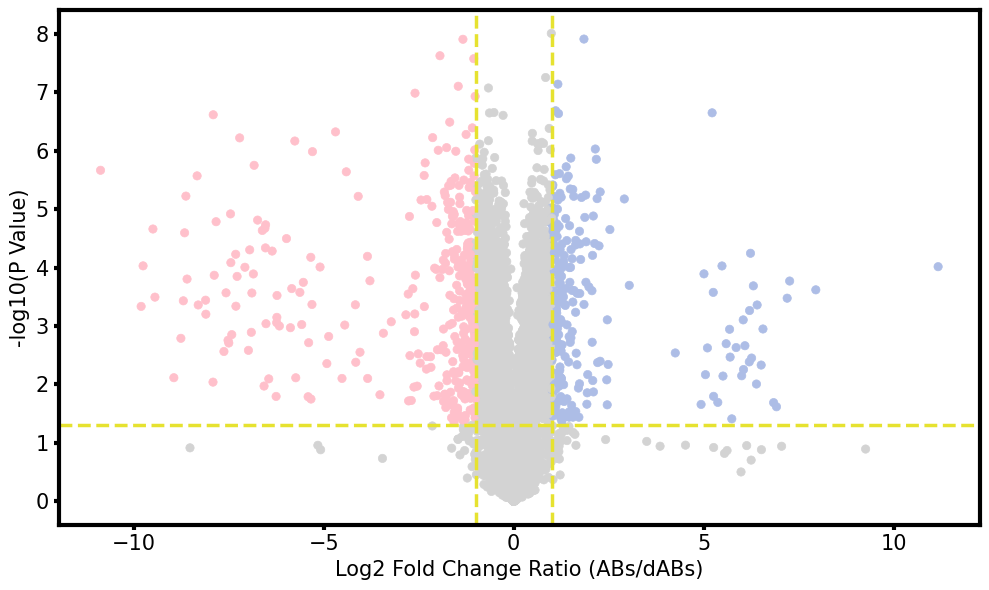

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ==================== 第 1 步：读取数据 ====================
input_file = r"E:\python-pro\ICA\组学分析\danbai_data\raw data\20241107-CQT2024101111-F001-4D Direct DIA定量蛋白组-分析报告\20241107-CQT2024101111-F001-4D Direct DIA定量蛋白组-分析报告\1.Report Document\Differentially_expressed_statistics.xlsx"
print(f"正在读取文件: {input_file}")
df = pd.read_excel(input_file, sheet_name='ABs_vs_dABs')

# 检查必要的列是否存在
required_columns = ['Accession', 'ABs', 'dABs', 'P.Value']
for col in required_columns:
    if col not in df.columns:
        raise ValueError(f"Excel 中找不到必需的列: '{col}'")

# ==================== 第 2 步：数据计算与处理 ====================
print("正在处理数据计算...")
# 1. 处理 0 值：当ABs或dABs列中任意一个值为0时，对这一行的两个列都加1（防止除以0）
mask = (df['ABs'] == 0) | (df['dABs'] == 0)
df.loc[mask, ['ABs', 'dABs']] += 1

# 2. 计算 Fold Change Ratio (倍数)
df['reFold.Change.Ratio'] = df['ABs'] / df['dABs']

# 3. 计算 Log2 Fold Change
df['relog2Fold.Change.Ratio'] = np.log2(df['reFold.Change.Ratio'])

# 4. 清理空值并确保数据格式正确
df = df.dropna(subset=['P.Value', 'relog2Fold.Change.Ratio'])
df = df[df['P.Value'].apply(lambda x: isinstance(x, (int, float)))]
df = df[df['relog2Fold.Change.Ratio'].apply(lambda x: isinstance(x, (int, float)))]

# 5. 计算 -log10(P.Value)
df['-log10(P.Value)'] = -np.log10(df['P.Value'])

# ==================== 第 3 步：定义显著性并打标签 ====================
conditions = [
    (df['P.Value'] < 0.05) & (df['relog2Fold.Change.Ratio'] > 1),   # 显著上调
    (df['P.Value'] < 0.05) & (df['relog2Fold.Change.Ratio'] < -1),  # 显著下调
    (df['P.Value'] >= 0.05) | (df['relog2Fold.Change.Ratio'].between(-1, 1)) # 不显著
]
choices = ['#ADBDE6', 'pink', 'lightgrey'] # 对应颜色：淡蓝，粉红，浅灰
df['Significance'] = np.select(conditions, choices, default='lightgrey')

# 保存计算结果到桌面
output_file = r'C:\Users\Administrator\Desktop\Processed_Result.xlsx'
df.to_excel(output_file, index=False)
print(f"数据计算完毕，完整结果已保存至: {output_file}")

# 打印出显著变化的数据名称
light_blue_pink_data = df[df['Significance'].isin(['#ADBDE6', 'pink'])]
print(f"\n共找到 {len(light_blue_pink_data)} 个显著变化的数据：")
for index, row in light_blue_pink_data.iterrows():
    status = "上调 (淡蓝色)" if row['Significance'] == '#ADBDE6' else "下调 (粉红色)"
    print(f"Accession: {row['Accession']}, 状态: {status}")
output_file = r'C:\Users\Administrator\Desktop\Light_Blue_Pink_Data_2.xlsx'
light_blue_pink_data.to_excel(output_file, index=False)
print(f"Light Blue and Pink Data saved to {output_file}")
# ==================== 第 4 步：绘制火山图 ====================
print("\n正在生成火山图...")
plt.figure(figsize=(10, 6))

# 画散点
sns.scatterplot(
    data=df, 
    x='relog2Fold.Change.Ratio', 
    y='-log10(P.Value)', 
    hue='Significance', 
    palette={'#ADBDE6': '#ADBDE6', 'pink': 'pink', 'lightgrey': 'lightgrey'}, 
    edgecolor=None
)

# 添加参考线 (阈值线)
plt.axhline(y=-np.log10(0.05), color='#E6E230', linestyle='--', linewidth=2.5) # 横线 P=0.05
plt.axvline(x=1, color='#E6E230', linestyle='--', linewidth=2.5)               # 竖线 右侧
plt.axvline(x=-1, color='#E6E230', linestyle='--', linewidth=2.5)              # 竖线 左侧

# 设置图表样式
plt.xlabel('Log2 Fold Change Ratio (ABs/dABs)', fontsize=15)
plt.ylabel('-log10(P Value)', fontsize=15)
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)

# 加粗边框和刻度线
for spine in plt.gca().spines.values():
    spine.set_linewidth(3)
plt.gca().tick_params(width=3)

# 移除图例
plt.gca().legend().remove()

# 显示图片
plt.tight_layout()
plt.show()